In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25,s26])
train_df = train_df[train_df['MIN'] > 10]  
train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
# val_df = s25
# val_df = val_df[val_df['MIN'] > 10] 
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
# print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")
train_df.sample(5)

Player 1713: PTS range capped [0.0, 16.0]
Player 2199: PTS range capped [0.0, 9.7]
Player 2544: PTS range capped [10.6, 46.4]
Player 2546: PTS range capped [1.9, 29.0]
Player 2594: PTS range capped [0.0, 20.9]
Player 2617: PTS range capped [0.0, 23.0]
Player 2730: PTS range capped [0.0, 21.0]
Player 2738: PTS range capped [0.0, 12.8]
Player 2747: PTS range capped [0.1, 10.8]
Player 2772: PTS range capped [0.0, 21.0]
Player 101107: PTS range capped [0.0, 21.5]
Player 101108: PTS range capped [0.0, 30.0]
Player 101133: PTS range capped [2.0, 23.6]
Player 101139: PTS range capped [0.0, 20.5]
Player 101141: PTS range capped [0.0, 18.8]
Player 101150: PTS range capped [1.8, 32.5]
Player 200746: PTS range capped [2.0, 37.7]
Player 200752: PTS range capped [0.0, 22.0]
Player 200755: PTS range capped [0.0, 31.0]
Player 200757: PTS range capped [0.0, 9.0]
Player 200765: PTS range capped [0.0, 20.3]
Player 200768: PTS range capped [0.0, 32.0]
Player 200782: PTS range capped [0.0, 18.2]
Player 20

,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,percentagePointsFreeThrow_ROLLING_AVG_5,CFGA_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,PTS_ROLLING_AVG_7,AST_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3_PCT_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,FT_PCT_ROLLING_AVG_7,TOV_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,PACE_ROLLING_AVG_7,PIE_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,POSS_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,percentagePointsPaint_ROLLING_AVG_7,percentagePointsMidrange2pt_ROLLING_AVG_7,percentagePoints3pt_ROLLING_AVG_7,percentagePointsFreeThrow_ROLLING_AVG_7,CFGA_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt

In [3]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', #new
    'IS_ROLE_TIER', #new
    'IS_BENCH_TIER', #new
    'STARTING_X_BENCH_TIER', #new
    'STARTING_X_ROLE_TIER', #new
    'STARTING_X_STARTER_TIER', #new
    'GUARD',
    'FORWARD',
    'CENTER',
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    
    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',
    'PTS_ROLLING_AVG_5',  #new      
    'PTS_ROLLING_AVG_40', #new
    'PTS_TREND_LAST_5', #new
    'MIN_TREND_LAST_5', #new
    'PTS_PER_MIN_X_USG',
    'PTS_LAG_2',
    'PTS_VOLATILITY_25_TO_DATE',
    'PTS_EXTREME_VOLATILITY',
    'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGA_VOLATILITY_10_TO_DATE',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    'USG_PCT_LAG_1',
    'USG_PCT_VOLATILITY_5_TO_DATE',
    'TS_PCT_ROLLING_AVG_25',
    'TS_PCT_VOLATILITY_10_TO_DATE',
    'PIE_AVG_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'FG_PCT_AVG_TO_DATE',
    'CFGA_ROLLING_AVG_25',
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'FGM_STD_LAST_5',
    'FGM_STD_LAST_10',
    'FGM_STD_LAST_15',
    'FTM_STD_LAST_5',
    'FTM_STD_LAST_15',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'USAGE_X_EFFICIENCY', #new
    'PTS_PER_POSSESSION', #new

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_GUARD_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_DEF_3PT_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'OPP_FORWARD_DEF_FG_PCT_ALLOWED',
    'OPP_FORWARD_DEF_3PT_PCT_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_CENTER_DEF_3PT_PCT_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_ADJUSTED_EXPECTED_PTS', #new

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_AWAY_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_AWAY_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_AWAY_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_AWAY_FTA_DELTA',
    'PTS_BASELINE_x_HOME', #new 

 ]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('PLAYER_MISSED_LAST')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=70,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

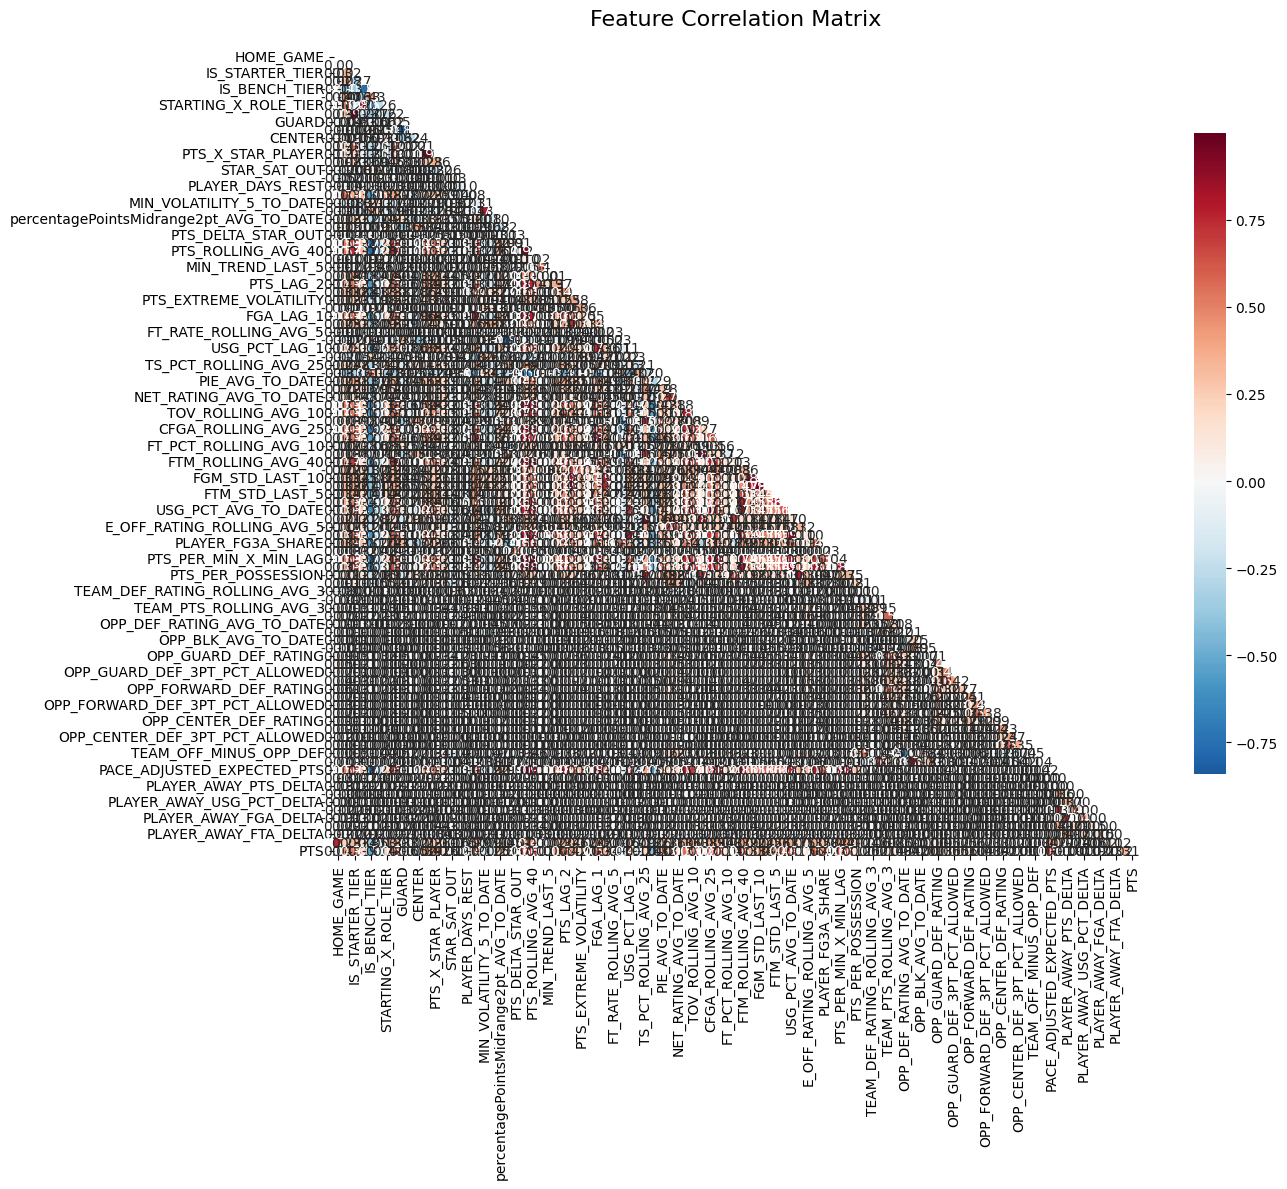

TOP 10 FEATURES MOST CORRELATED WITH TARGET:
 1. PTS_ROLLING_AVG_40             0.679
 2. PACE_ADJUSTED_EXPECTED_PTS     0.661
 3. PTS_ROLLING_AVG_5              0.661
 4. PTS_PER_MIN_X_MIN_LAG          0.655
 5. FTM_ROLLING_AVG_40             0.604
 6. USAGE_X_EFFICIENCY             0.602
 7. CFGA_ROLLING_AVG_25            0.598
 8. USG_PCT_AVG_TO_DATE            0.597
 9. FGA_LAG_1                      0.585
10. USG_PCT_ROLLING_AVG_5          0.574
REMOVED: PTS_ROLLING_AVG_5              (corr with PACE_ADJUSTED_EXPECTED_PTS: 0.999)
REMOVED: IS_STARTER_TIER                (corr with STARTING_X_STARTER_TIER: 0.991)
REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.962)

SUMMARY:
Original features: 98
Removed features: 3
Final features: 95


In [4]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### NGBOOST MODEL

In [ ]:
model, params = fit_ngboost_bayes(
    train_df, None, top_features, 'PTS',
    n_iter=15,  
    distribution=Normal
)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


In [8]:
dist = model.pred_dist(val_df[top_features])
y_true = val_df["PTS"].to_numpy()
y_hat  = dist.loc  # predictive mean

rmse = np.sqrt(np.mean((y_hat - y_true)**2))
mae  = np.mean(np.abs(y_hat - y_true))
r2   = 1 - np.sum((y_true - y_hat)**2)/np.sum((y_true - y_true.mean())**2)
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
nll = -np.mean(dist.logpdf(y_true))
print("NLL:", nll)
lower = dist.ppf(0.025)
upper = dist.ppf(0.975)
coverage = np.mean((y_true >= lower) & (y_true <= upper))
width = np.mean(upper - lower)
print("95% coverage:", coverage, "avg width:", width)
pit = dist.cdf(y_true)
# Quick uniformity check:
print("PIT mean:", pit.mean(), "std:", pit.std())
stds = dist.scale
corr = np.corrcoef(np.abs(y_true - y_hat), stds)[0,1]
print("Corr(|error|, std):", corr)

# Calibration check
print("\n=== CALIBRATION DIAGNOSTICS ===")
coverage_cal, expected_cal = evaluate_calibration(model, val_df, top_features, 'PTS', alpha=0.05)
print(f"Actual coverage: {coverage_cal:.1%}, Expected: {expected_cal:.1%}")
print(f"Coverage gap: {(coverage_cal - expected_cal)*100:.1f} percentage points")

# Check per-player volatility
player_volatility = val_df.groupby('PLAYER_ID').agg({
    'PTS': ['mean', 'std', 'count']
}).reset_index()
player_volatility.columns = ['PLAYER_ID', 'MEAN_PTS', 'STD_PTS', 'GAME_COUNT']
print("\nTop 10 most volatile players:")
print(player_volatility.nlargest(10, 'STD_PTS')[['PLAYER_ID', 'MEAN_PTS', 'STD_PTS']])

# Check if sigma is too high relative to actual volatility
print(f"\nModel sigma stats: mean={stds.mean():.2f}, median={np.median(stds):.2f}, std={stds.std():.2f}")
print(f"Actual PTS std: {player_volatility['STD_PTS'].mean():.2f} (mean across all players)")
print(f"Model sigma is {stds.mean() / player_volatility['STD_PTS'].mean():.1f}x actual volatility")

RMSE: 5.920, MAE: 4.643, R²: 0.507
NLL: 3.1597096420234982
95% coverage: 0.9483891431419639 avg width: 21.877863615501827
PIT mean: 0.485483471847353 std: 0.29498174644100844
Corr(|error|, std): 0.246759064992692

=== CALIBRATION DIAGNOSTICS ===
Actual coverage: 94.8%, Expected: 95.0%
Coverage gap: -0.2 percentage points

Top 10 most volatile players:
     PLAYER_ID   MEAN_PTS    STD_PTS
220    1629656  14.911781  10.201597
44      203468  21.095536  10.121230
259    1630205  10.883333  10.031633
15      201939  24.513286   9.786601
247    1630178  26.307308   9.638942
177    1629022  14.343529   9.264859
74      203999  29.556143   9.193505
234    1630162  27.534487   9.164001
35      203076  25.437500   9.090163
225    1629673  20.436176   9.025612

Model sigma stats: mean=5.58, median=5.51, std=1.12
Actual PTS std: 5.42 (mean across all players)
Model sigma is 1.0x actual volatility


In [9]:
# Apply calibration to reduce underprediction and interval width
print("Applying isotonic calibration...")
calibrator = calibrate_predictions(model, train_df, top_features, 'PTS', method='isotonic')

# Get calibrated predictions on validation set
calibrated_preds = predict_calibrated_mean(model, calibrator, val_df, top_features, method='isotonic')

# Compare calibrated vs uncalibrated
print("\n=== COMPARISON: UNCALIBRATED vs CALIBRATED ===")
print(f"Uncalibrated RMSE: {rmse:.3f}")
calibrated_rmse = np.sqrt(np.mean((calibrated_preds - y_true)**2))
print(f"Calibrated RMSE:   {calibrated_rmse:.3f}")
print(f"Improvement:       {((rmse - calibrated_rmse) / rmse * 100):.1f}%")

# For production use, you can apply calibration before saving
# calibrated_mean = predict_calibrated_mean(model, calibrator, test_df, top_features, method='isotonic')


Applying isotonic calibration...

=== COMPARISON: UNCALIBRATED vs CALIBRATED ===
Uncalibrated RMSE: 5.920
Calibrated RMSE:   5.921
Improvement:       -0.0%


In [11]:
# Add predictions to validation dataframe
val_df['prediction'] = y_hat
val_df['error'] = val_df['prediction'] - val_df['PTS']

# Check bias by player tier
player_stats = val_df.groupby('PLAYER_ID').agg({
    'PTS': 'mean',
    'prediction': 'mean',
    'error': 'mean'  # prediction - actual
}).reset_index()

# Stars (>20 PPG)
stars = player_stats[player_stats['PTS'] > 20]
print(f"\n=== PREDICTION BIAS BY PLAYER TIER ===")
print(f"Star bias: {stars['error'].mean():.2f} points (n={len(stars)})")

# Role players (10-20 PPG)
role = player_stats[(player_stats['PTS'] >= 10) & (player_stats['PTS'] <= 20)]
print(f"Role player bias: {role['error'].mean():.2f} points (n={len(role)})")

# Bench (<10 PPG)
bench = player_stats[player_stats['PTS'] < 10]
print(f"Bench bias: {bench['error'].mean():.2f} points (n={len(bench)})")

# Overall bias
print(f"\nOverall bias: {val_df['error'].mean():.2f} points")


=== PREDICTION BIAS BY PLAYER TIER ===
Star bias: -1.25 points (n=52)
Role player bias: -0.80 points (n=181)
Bench bias: 0.66 points (n=305)

Overall bias: -0.01 points


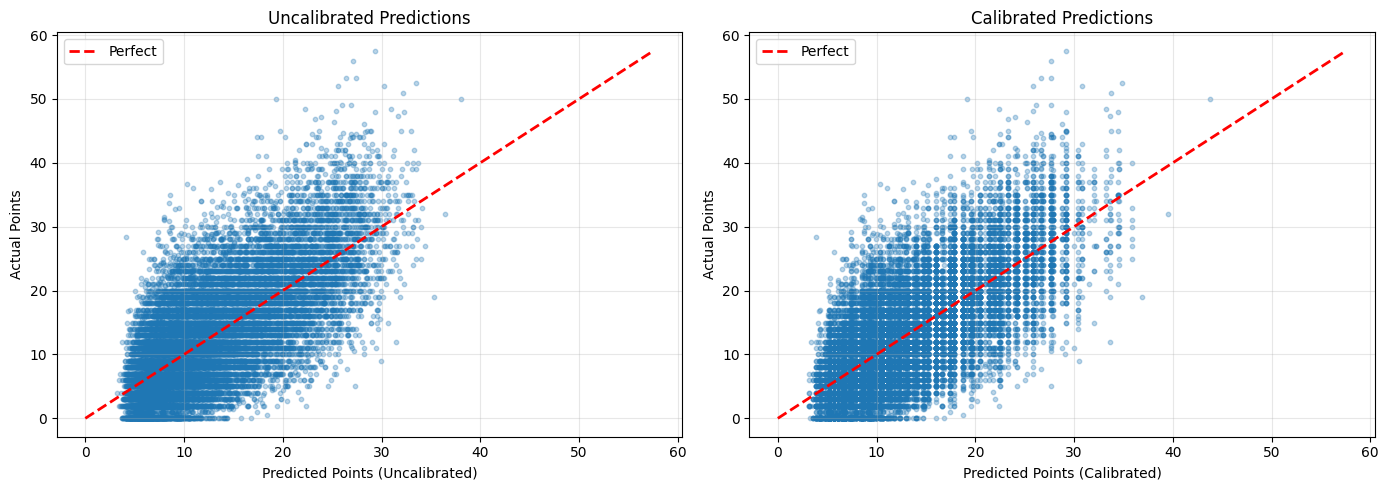

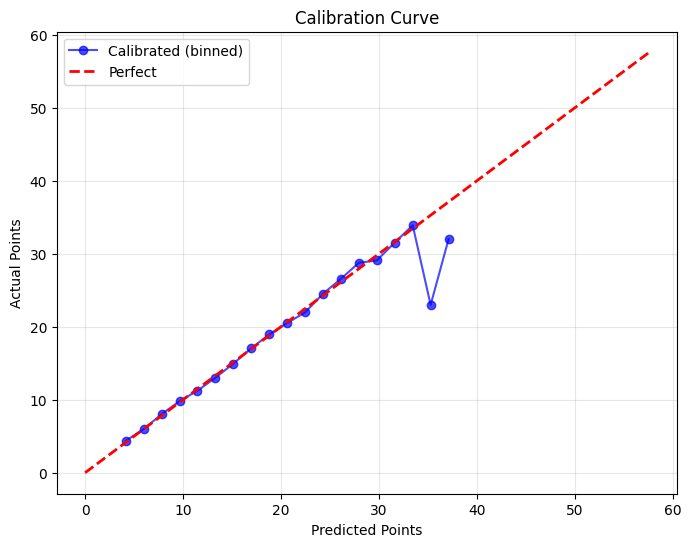

In [14]:
# Visualize calibration: predicted vs actual with calibration line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uncalibrated predictions
axes[0].scatter(y_hat, y_true, alpha=0.3, s=10)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Predicted Points (Uncalibrated)')
axes[0].set_ylabel('Actual Points')
axes[0].set_title('Uncalibrated Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calibrated predictions
axes[1].scatter(calibrated_preds, y_true, alpha=0.3, s=10)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Predicted Points (Calibrated)')
axes[1].set_ylabel('Actual Points')
axes[1].set_title('Calibrated Predictions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot calibration curve
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Bin predictions and compute average actual values
bins = np.linspace(y_hat.min(), y_hat.max(), 20)
bin_indices = np.digitize(y_hat, bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_actuals = [y_true[bin_indices == i].mean() for i in range(1, len(bins))]
bin_preds = [y_hat[bin_indices == i].mean() for i in range(1, len(bins))]

ax.plot(bin_centers, bin_actuals, 'bo-', label='Calibrated (binned)', alpha=0.7)
ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Predicted Points')
ax.set_ylabel('Actual Points')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [15]:
# Apply tier-specific calibration
from MODELS.ngboostModel import predict_mean_with_tier_calibration

tier_calibrated_preds = predict_mean_with_tier_calibration(
    model, val_df, top_features, 
    player_avg_col='PTS_AVG_TO_DATE'
)

# Add to dataframe
val_df['tier_calibrated'] = tier_calibrated_preds
val_df['tier_error'] = val_df['tier_calibrated'] - val_df['PTS']

# Compare all calibration methods
print("=== CALIBRATION COMPARISON ===")
tier_cal_rmse = np.sqrt(np.mean((tier_calibrated_preds - y_true)**2))
print(f"Uncalibrated RMSE:    {rmse:.3f}")
print(f"Isotonic RMSE:        {calibrated_rmse:.3f}")
print(f"Tier-calibrated RMSE: {tier_cal_rmse:.3f}")
print(f"Tier improvement:     {((rmse - tier_cal_rmse) / rmse * 100):.2f}%")

# Check tier bias AFTER calibration
val_df['player_tier'] = val_df['PTS_ROLLING_AVG_15'].apply(
    lambda x: 'Star' if x > 20 else ('Role' if x >= 10 else 'Bench')
)

tier_bias_after = val_df.groupby('player_tier')['tier_error'].agg(['mean', 'count'])
print("\n=== Tier Bias AFTER Calibration ===")
print(tier_bias_after)


=== CALIBRATION COMPARISON ===
Uncalibrated RMSE:    5.920
Isotonic RMSE:        5.921
Tier-calibrated RMSE: 5.977
Tier improvement:     -0.95%

=== Tier Bias AFTER Calibration ===
                 mean  count
player_tier                 
Bench       -0.664968  10832
Role         0.730173   8287
Star         1.231406   2950


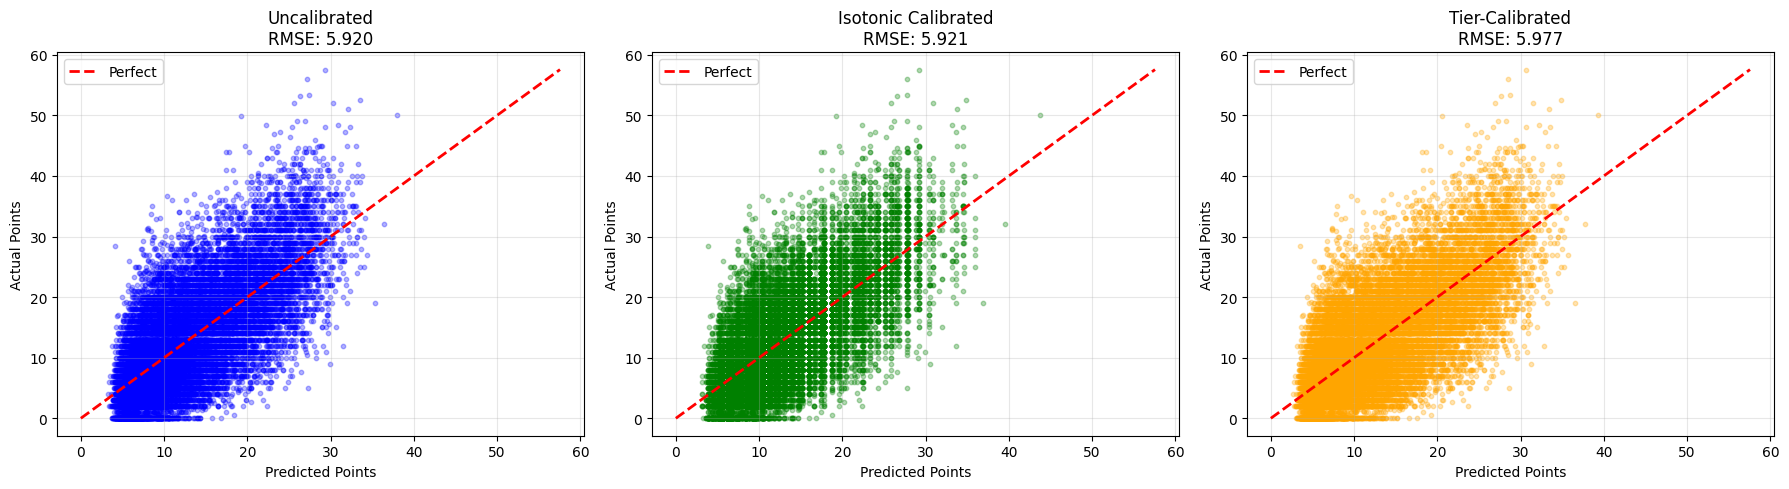

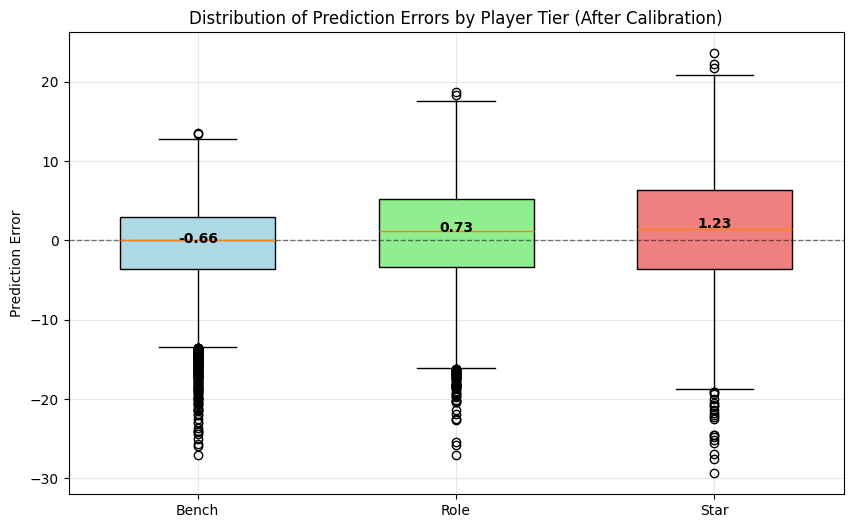

In [16]:
# Visualize all three calibration methods side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Uncalibrated
axes[0].scatter(y_hat, y_true, alpha=0.3, s=10, c='blue')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Predicted Points')
axes[0].set_ylabel('Actual Points')
axes[0].set_title(f'Uncalibrated\nRMSE: {rmse:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Isotonic
axes[1].scatter(calibrated_preds, y_true, alpha=0.3, s=10, c='green')
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Predicted Points')
axes[1].set_ylabel('Actual Points')
axes[1].set_title(f'Isotonic Calibrated\nRMSE: {calibrated_rmse:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Tier-specific
axes[2].scatter(tier_calibrated_preds, y_true, alpha=0.3, s=10, c='orange')
axes[2].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[2].set_xlabel('Predicted Points')
axes[2].set_ylabel('Actual Points')
axes[2].set_title(f'Tier-Calibrated\nRMSE: {tier_cal_rmse:.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plot of errors by tier
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
tier_order = ['Bench', 'Role', 'Star']
val_df_plot = val_df.copy()
val_df_plot['player_tier'] = pd.Categorical(val_df_plot['player_tier'], categories=tier_order)

for i, tier in enumerate(tier_order):
    tier_data = val_df_plot[val_df_plot['player_tier'] == tier]['tier_error'].values
    bp = ax.boxplot(tier_data, positions=[i], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=['lightblue', 'lightgreen', 'lightcoral'][i]))
    ax.text(i, tier_data.mean(), f'{tier_data.mean():.2f}', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xticklabels(tier_order)
ax.set_ylabel('Prediction Error')
ax.set_title('Distribution of Prediction Errors by Player Tier (After Calibration)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3)
plt.show()


### Plot SHAP values per position to verify the model leans on the right drivers

In [ ]:
# analyze_shap(xgbModel, test_df, top_features, 'PTS')

In [8]:
# joblib.dump(xgbModel, 'SAVED_MODELS/XGBOOST_PTS_MODEL.pkl')
joblib.dump(model, 'SAVED_MODELS/NGBOOST_PTS_MODEL.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']